In [1]:
#%pip install scipy
#%pip install statsmodels

In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from scipy.stats import spearmanr, pearsonr
import glob

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Percorso della cartella con i CSV puliti
#path = "/content/drive/MyDrive/Desktop/Magistrale/IoT_ESP_SleepSense/Misurazioni/*.csv"
path = "C:/Users/leopi/Il mio Drive/Desktop/Magistrale/IoT_ESP_SleepSense/Misurazioni/*.csv"

# Caricamento file
all_files = glob.glob(path)
dfs = [pd.read_csv(f) for f in all_files]
df_all = pd.concat(dfs, ignore_index=True)

# Pulizia e conversione tipi
df_all["_time"] = pd.to_datetime(df_all["_time"], utc=True, errors="coerce", format="mixed")
cols_to_numeric = ["humidity", "light", "mic", "temperature", "is_moving", "accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]
df_all[cols_to_numeric] = df_all[cols_to_numeric].apply(pd.to_numeric, errors="coerce")

# Rimuovo eventuali righe con valori nulli
df_all = df_all.dropna(subset=cols_to_numeric)

print("Dimensione dataset:", df_all.shape)
df_all.head()



Dimensione dataset: (4667, 16)


,_time,_measurement,host,location,room,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,humidity,light,mic,temperature,is_moving
0,2025-11-07 00:20:20+00:00,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.133871,0.022258,1.032581,0.224516,0.271613,0.001290,59.800000,0.0,13.258065,21.000000,0
1,2025-11-07 00:21:17.500000+00:00,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.133882,0.022235,1.033529,0.282118,0.290706,0.007412,59.683529,0.0,13.070588,21.037647,0
2,2025-11-07 00:22:15+00:00,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.133837,0.022326,1.032558,0.284651,0.336512,-0.006395,59.508140,0.0,13.930233,21.100000,0
3,2025-11-07 00:23:12.500000+00:00,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.133563,0.022529,1.033103,0.297471,0.291034,-0.036782,59.416092,0.0,11.413793,21.116092,0
4,2025-11-07 00:24:10+00:00,corso_IoT,ESP_LEOPIZZI,Lecce,Stanza,0.132442,0.022093,1.033605,0.310116,0.344651,0.004070,59.329070,0.0,12.790698,21.200000,0


In [5]:

# Plot dei dati
fig = px.line(df_all, x="_time", y=cols_to_numeric, title="Plot delle variabili nel tempo")
fig.update_layout(xaxis_title="Time", yaxis_title="Sensor Values")
fig.show()

# Plot dei dati senza tempo
fig = px.line(df_all, y=cols_to_numeric, title="Plot delle variabili affiancate (senza tempo)")
fig.update_layout(xaxis_title="Index", yaxis_title="Sensor Values")
fig.show()

# Violin plot
fig = px.violin(df_all, y=cols_to_numeric, box=True, points="all",
                title="Distribuzione dei valori dei sensori (Violin Plot)")
fig.show()


In [6]:
# Matrici di correlazione ===
cols = ["humidity", "light", "mic", "temperature", "is_moving"]

# Pearson
pear1 = df_all[cols].corr(method="pearson")["is_moving"]

# Spearman
spear1 = df_all[cols].corr(method="spearman")["is_moving"]

# Kendall
kend1 = df_all[cols].corr(method="kendall")["is_moving"]

variables = ["humidity", "light", "mic", "temperature"]
pear1 = pear1[variables]
spear1 = spear1[variables]
kend1 = kend1[variables]

df_compare = pd.DataFrame({
    "Variabile": variables,
    "Pearson": pear1,
    "Spearman": spear1,
    "Kendall": kend1
})

In [20]:
# Confronto delle correlazioni
fig = go.Figure()
for metric, color in [
    ("Pearson", "blue"),
    ("Spearman", "green"),
    ("Kendall", "orange")
]:
    fig.add_trace(go.Bar(
        x=df_compare["Variabile"],
        y=df_compare[f"{metric}"],
        name=f"{metric}",
        marker=dict(color=color, opacity=0.55)
    ))

fig.update_layout(
    title="Correlazione",
    xaxis_title="Variabile",
    yaxis_title="Correlazione",
    barmode="group",
    yaxis=dict(range=[-1,1])
)
fig.show()

# Matrice di confusione
corr_matrix = df_all[cols].corr()
df_rounded = corr_matrix.copy()
for col in cols:
    df_rounded[col] = df_rounded[col].round(2)
fig = ff.create_annotated_heatmap(
    z=df_rounded.values,
    x=list(df_rounded.columns),
    y=list(df_rounded.columns),
    colorscale="Viridis",
    showscale=True,
    zmin=-1,
    zmax=1
)
fig.update_layout(title="Matrice di correlazione dei sensori")
fig.show()

# Scatter plot 
fig = px.scatter_matrix(df_all, dimensions=cols,title="Scatter Matrix")
fig.update_layout(height=800, width=800)
fig.show()



<Figure size 1200x400 with 0 Axes>

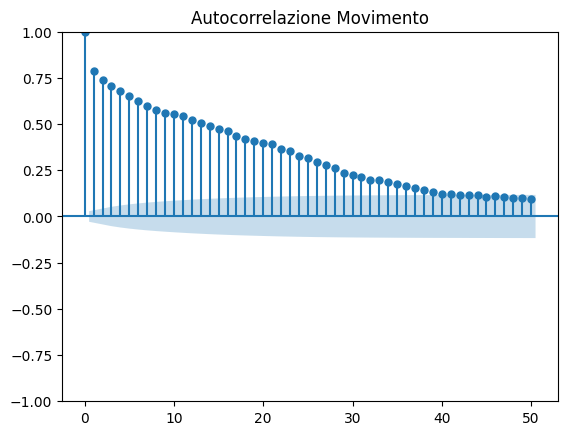

<Figure size 1200x400 with 0 Axes>

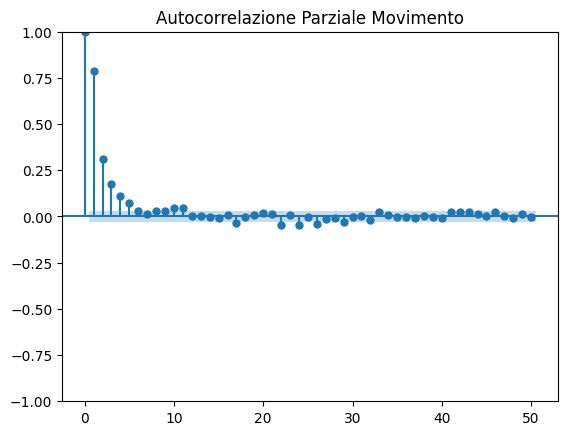

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plot_acf(df_all["is_moving"], lags=50)
plt.title("Autocorrelazione Movimento")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df_all["is_moving"], lags=50)
plt.title("Autocorrelazione Parziale Movimento")
plt.show()

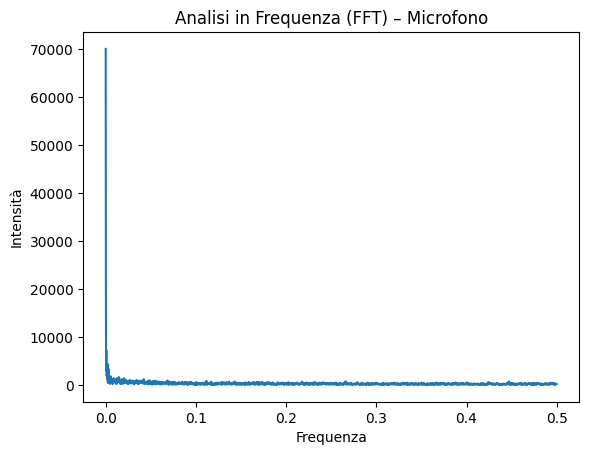

In [9]:
import numpy as np
import matplotlib.pyplot as plt

signal = df_all["mic"].values
fft_vals = np.abs(np.fft.rfft(signal))
freqs = np.fft.rfftfreq(len(signal), d=1)

plt.plot(freqs, fft_vals)
plt.title("Analisi in Frequenza (FFT) – Microfono")
plt.xlabel("Frequenza")
plt.ylabel("Intensità")
plt.show()

In [10]:
def lag_corr(a, b, lag=0):
    return a.shift(lag).corr(b)

for v in ["humidity", "light", "mic", "temperature"]:
    print(f"\n### Lag correlation con {v}")
    for lag in [0, 1, 5, 10, 20]:
        print(f"Lag {lag}: {lag_corr(df_all[v], df_all['is_moving'], lag):.3f}")


### Lag correlation con humidity
Lag 0: -0.062
Lag 1: -0.062
Lag 5: -0.061
Lag 10: -0.059
Lag 20: -0.055

### Lag correlation con light
Lag 0: 0.189
Lag 1: 0.186
Lag 5: 0.171
Lag 10: 0.152
Lag 20: 0.099

### Lag correlation con mic
Lag 0: 0.153
Lag 1: 0.153
Lag 5: 0.148
Lag 10: 0.149
Lag 20: 0.134

### Lag correlation con temperature
Lag 0: -0.100
Lag 1: -0.100
Lag 5: -0.098
Lag 10: -0.096
Lag 20: -0.093


In [11]:
window = 200

for v in ["humidity", "light", "mic", "temperature"]:
    df_all[f"rollcorr_{v}"] = (
        df_all[v].rolling(window).corr(df_all["is_moving"])
    )

    fig = px.line(df_all, y=f"rollcorr_{v}", title=f"Rolling Correlation – {v}")
    fig.update_layout(yaxis=dict(range=[-1,1]))
    fig.show()

In [13]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = df_all[["humidity","light","mic","temperature"]]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3)
df_all["cluster"] = kmeans.fit_predict(X_scaled)

fig = px.scatter_3d(
    df_all, x="humidity", y="temperature", z="mic",
    color="cluster", title="Cluster dei pattern ambientali"
)
fig.show()

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df_all[["humidity", "light", "mic", "temperature"]]
y = df_all["is_moving"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)

print(classification_report(y_test, clf.predict(X_test)))

importance = clf.coef_[0]
fig = px.bar(x=X.columns, y=importance, title="Importanza delle variabili nella previsione del movimento")
fig.show()

              precision    recall  f1-score   support

           0       0.83      0.99      0.90       767
         100       0.69      0.07      0.12       167

    accuracy                           0.83       934
   macro avg       0.76      0.53      0.51       934
weighted avg       0.80      0.83      0.76       934



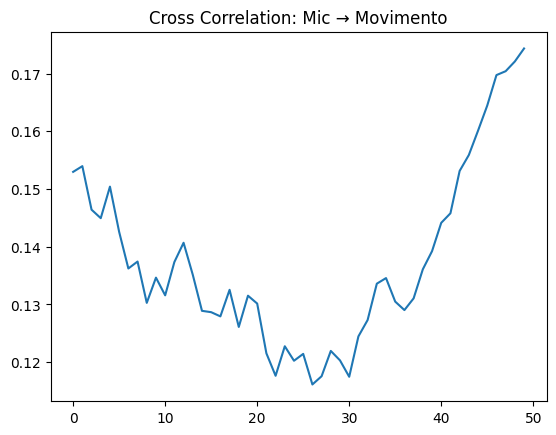

In [15]:
from statsmodels.tsa.stattools import ccf

cross = ccf(df_all["mic"], df_all["is_moving"])[:50]
plt.plot(cross)
plt.title("Cross Correlation: Mic → Movimento")
plt.show()